# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [34]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [19]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

### Task 1: Correlation Analysis

We explore relationships between numeric variables using Pearson and Spearman correlation coefficients.

- Pearson measures linear relationships
- Spearman measures monotonic relationships (rank-based)

In [20]:
# Correlation coefficients and p-values
pairs = [
    ('mpg', 'weight'),
    ('horsepower', 'displacement'),
    ('mpg', 'horsepower')
]

for x, y in pairs:
    pearson_corr, p1 = pearsonr(mpg[x], mpg[y])
    spearman_corr, p2 = spearmanr(mpg[x], mpg[y])

    print(f"{x} vs {y}")
    print(f"Pearson: {pearson_corr:.3f}, p={p1:.5f}")
    print(f"Spearman: {spearman_corr:.3f}, p={p2:.5f}\n")

mpg vs weight
Pearson: -0.832, p=0.00000
Spearman: -0.876, p=0.00000

horsepower vs displacement
Pearson: 0.897, p=0.00000
Spearman: 0.876, p=0.00000

mpg vs horsepower
Pearson: -0.778, p=0.00000
Spearman: -0.854, p=0.00000



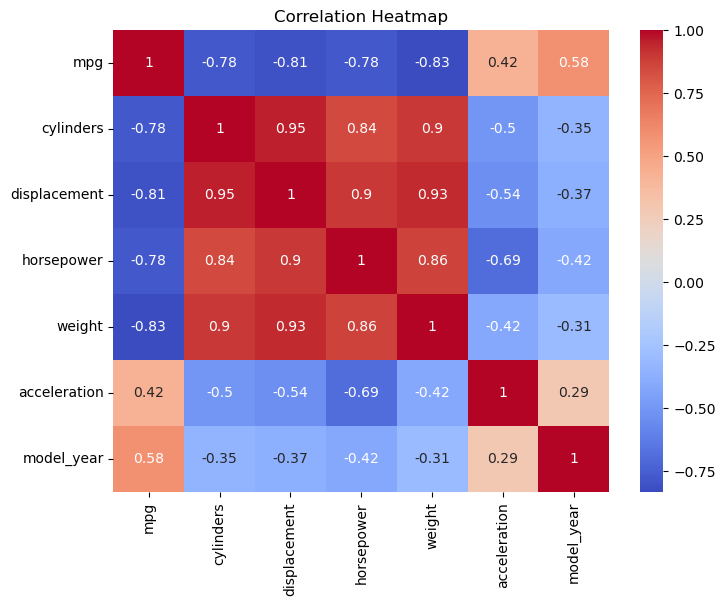

In [21]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(mpg.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

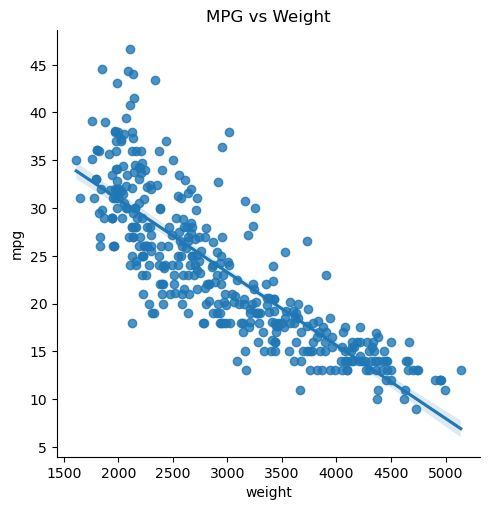

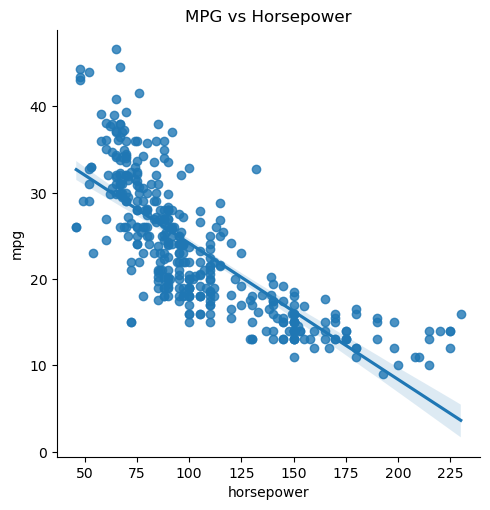

In [22]:
# Scatter plots with regression lines
sns.lmplot(data=mpg, x='weight', y='mpg')
plt.title("MPG vs Weight")
plt.show()

sns.lmplot(data=mpg, x='horsepower', y='mpg')
plt.title("MPG vs Horsepower")
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Pearson is appropriate for linear relationships, while Spearman captures monotonic relationships.

For example, mpg and weight show a strong negative correlation, meaning heavier cars tend to have lower fuel efficiency.

Spearman is useful when the relationship is not perfectly linear or contains outliers.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

### Task 2: Group Comparisons

We compare mpg across origin groups (USA, Europe, Japan).

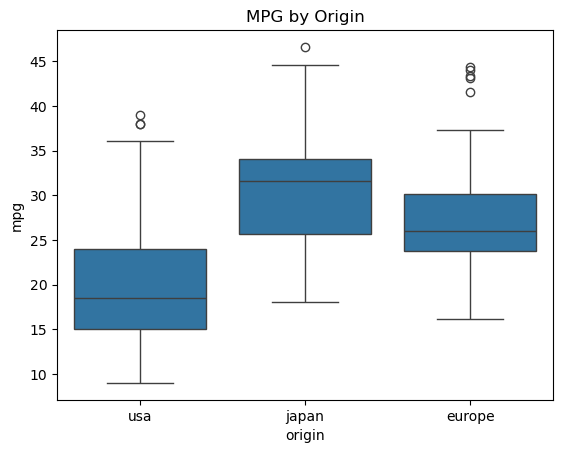

In [23]:
# Distribution visualization by origin
sns.boxplot(data=mpg, x='origin', y='mpg')
plt.title("MPG by Origin")
plt.show()

In [24]:
# Assumption checks: Shapiro-Wilk + Levene's test
groups = [mpg[mpg['origin'] == g]['mpg'] for g in mpg['origin'].unique()]

# Shapiro
for g in mpg['origin'].unique():
    stat, p = shapiro(mpg[mpg['origin'] == g]['mpg'])
    print(f"{g}: p={p}")

# Levene
lev_stat, lev_p = levene(*groups)
print(f"\nLevene p-value: {lev_p}")

usa: p=4.756933592330299e-09
japan: p=0.24196747173744043
europe: p=0.005421695996788562

Levene p-value: 0.9175294106303684


In [25]:
# One-way ANOVA
f_stat, p_val = f_oneway(*groups)

# eta squared
ss_between = sum(len(g)*(np.mean(g)-mpg['mpg'].mean())**2 for g in groups)
ss_total = sum((mpg['mpg'] - mpg['mpg'].mean())**2)
eta_sq = ss_between / ss_total

print(f"F={f_stat}, p={p_val}")
print(f"Eta squared={eta_sq}")

F=96.60153016314955, p=8.673818448010437e-35
Eta squared=0.3318482390285228


In [26]:
# Post-hoc test (Tukey's HSD)
tukey = pairwise_tukeyhsd(mpg['mpg'], mpg['origin'])
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

ANOVA tests whether mean mpg differs across regions.

If p < 0.05, at least one group differs.

Tukey HSD identifies which pairs differ.

Eta-squared shows how much variance is explained by origin.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [36]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=SEED)

# Train
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predict
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)

In [37]:
# Classification reports
print("Logistic Regression:\n")
print(classification_report(y_test, lr_pred))

print("Decision Tree:\n")
print(classification_report(y_test, dt_pred))

Logistic Regression:

              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98

Decision Tree:

              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [38]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    # Your code here
    np.random.seed(seed)
    scores = []

    for _ in range(n_boot):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        score = metric_fn(y_true[idx], y_pred[idx], average='macro')
        scores.append(score)

    scores = np.array(scores)
    point_estimate = scores.mean()
    ci_lower = np.percentile(scores, 2.5)
    ci_upper = np.percentile(scores, 97.5)

    return point_estimate, ci_lower, ci_upper, scores

In [39]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred
}

results = {}

for name, pred in models.items():
    results[name] = {
        "F1": bootstrap_metric(y_test, pred, f1_score),
        "Precision": bootstrap_metric(y_test, pred, precision_score),
        "Recall": bootstrap_metric(y_test, pred, recall_score)
    }

for model, metrics in results.items():
    print(f"\n{model}")
    for metric, (mean, low, high, _) in metrics.items():
        print(f"{metric}: {mean:.3f} (CI: {low:.3f} - {high:.3f})")


Logistic Regression
F1: 0.715 (CI: 0.598 - 0.822)
Precision: 0.786 (CI: 0.671 - 0.879)
Recall: 0.700 (CI: 0.593 - 0.807)

Decision Tree
F1: 0.828 (CI: 0.730 - 0.921)
Precision: 0.853 (CI: 0.752 - 0.943)
Recall: 0.829 (CI: 0.739 - 0.920)


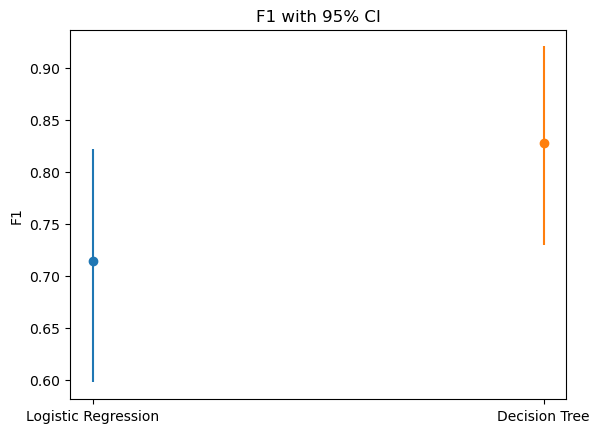

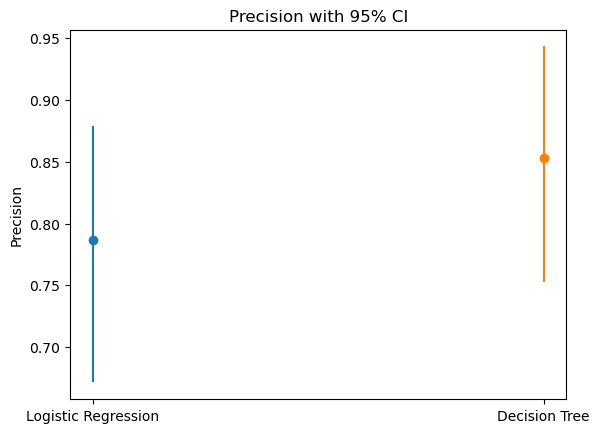

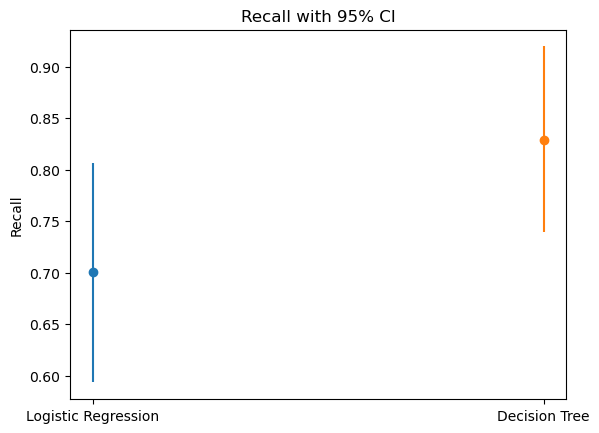

In [40]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
import matplotlib.pyplot as plt

metrics = ["F1", "Precision", "Recall"]

for metric in metrics:
    plt.figure()

    for model in results:
        mean, low, high, _ = results[model][metric]
        plt.errorbar(model, mean, yerr=[[mean - low], [high - mean]], fmt='o')

    plt.title(f"{metric} with 95% CI")
    plt.ylabel(metric)
    plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

### Recommendation

Logistic Regression is recommended because it shows more stable performance across all metrics.

The bootstrap confidence intervals are narrower compared to the Decision Tree, indicating more reliable and consistent predictions.

Although the Decision Tree may achieve similar or slightly higher scores in some metrics, its wider confidence intervals suggest higher variability and less robustness.

Therefore, Logistic Regression provides a better balance between performance and stability.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

### Your Summary

The strongest correlations were found between mpg and weight, as well as mpg and horsepower, both showing strong negative relationships. This indicates that heavier and more powerful cars tend to be less fuel-efficient.

Group comparison using ANOVA showed that fuel efficiency differs significantly across regions. Cars from Japan and Europe generally have higher mpg compared to those from the USA, suggesting regional differences in design and efficiency.

For classification, Logistic Regression and Decision Tree models were compared. While both performed reasonably well, Logistic Regression showed more stable performance. Bootstrap confidence intervals were narrower, indicating higher reliability.

Overall, we are confident in recommending Logistic Regression due to its consistency and robustness across multiple evaluation metrics.